## Data cleaning and Preprocessing

In [61]:
# adding necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [62]:
# opening the dataset
data_filepath = "train_data/group_01_train.csv"
data = pd.read_csv(data_filepath)
data

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f26,f27,f28,f29,f30,f31,f32,f33,f34,y
0,Source2,2019-02-27 16:33:43,25.885487,-80.209206,NaN,0.000,Lane blocked due to accident on I-95 Northboun...,I-95 S,Miami-Dade,FL,...,False,False,False,False,False,Day,Day,Day,Day,3
1,Source2,2019-07-16 14:48:06,33.652409,-112.093979,NaN,0.000,Accident on Bluefield Ave at 16th Ave.,N 16th Ave,Maricopa,AZ,...,False,False,False,False,False,Day,Day,Day,Day,2
2,Source1,2022-06-11 21:38:22,40.725697,-73.899985,-73.886415,0.728,Incident on I-495 EB near GRAND AVE Expect lon...,Long Island Expy E,Queens,NY,...,False,False,False,False,False,Day,Day,Day,Day,2
3,Source1,2020-06-15 17:49:03,26.717860,-80.090410,-80.090410,0.000,At I-95 - Accident.,Palm Beach Lakes Blvd,Palm Beach,FL,...,False,False,False,False,False,Day,Day,Day,Day,2
4,Source2,2019-03-14 05:20:13,35.097069,-81.667786,NaN,0.000,Accident on I-85 Southbound after Exit 92 SC-11.,I-85 S,Cherokee,SC,...,False,False,False,False,False,Night,Night,Night,Night,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Source1,2021-06-08 11:16:30,39.748838,-78.182017,-78.184897,1.826,Stationary traffic on I-70 E - US-522 S from U...,Pigeon Cove Rd,Fulton,PA,...,False,False,False,False,False,Day,Day,Day,Day,2
99996,Source1,2021-11-27 11:38:11,38.677148,-120.918362,-120.945269,1.824,Accident on Shingle Springs Dr (US-50) from Ca...,El Dorado Fwy W,El Dorado,CA,...,False,False,False,False,False,Day,Day,Day,Day,2
99997,Source2,2019-08-01 06:05:23,32.895851,-96.899300,NaN,0.000,Accident on Royal Ln at Emerald St.,Emerald St,Dallas,TX,...,False,False,False,False,False,Night,Night,Night,Day,2
99998,Source1,2021-11-11 23:09:47,28.460345,-81.311589,-81.312289,0.058,Incident on NORTH FRONTAGE RD near FORBES PL R...,N Frontage Rd,Orange,FL,...,False,False,False,False,False,Night,Night,Night,Night,4


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   f1      100000 non-null  object 
 1   f2      100000 non-null  object 
 2   f3      100000 non-null  float64
 3   f4      100000 non-null  float64
 4   f5      55938 non-null   float64
 5   f6      100000 non-null  float64
 6   f7      100000 non-null  object 
 7   f8      99865 non-null   object 
 8   f9      100000 non-null  object 
 9   f10     100000 non-null  object 
 10  f11     100000 non-null  object 
 11  f12     99898 non-null   object 
 12  f13     98483 non-null   object 
 13  f14     74251 non-null   float64
 14  f15     97752 non-null   float64
 15  f16     98233 non-null   float64
 16  f17     97742 non-null   float64
 17  f18     97780 non-null   object 
 18  f19     92639 non-null   float64
 19  f20     71752 non-null   float64
 20  f21     97760 non-null   object 
 21  f22     100

In [64]:
# number of duplicated rows 
data.duplicated().sum()

np.int64(19)

In [65]:
# delete duplicated rows
data = data.drop_duplicates()

In [66]:
# here we look at what percentage of the columns are null
missing_values = data.isna().sum().sort_values(ascending=False)
missing_percentage = missing_values[missing_values!=0]/len(data)*100
missing_percentage

f5     44.068373
f20    28.251368
f14    25.751893
f19     7.361399
f17     2.258429
f15     2.248427
f21     2.240426
f18     2.220422
f16     1.767336
f13     1.517288
f31     0.329063
f33     0.329063
f32     0.329063
f34     0.329063
f8      0.135026
f12     0.102019
dtype: float64

In [67]:
# dropping columns with missing percentage of more than 20%
over_miss_cols = missing_percentage[missing_percentage > 20].index
data = data.drop(columns=over_miss_cols)
print("Dropped columns:")
print(list(over_miss_cols))

Dropped columns:
['f5', 'f20', 'f14']


In [68]:
pd.DataFrame({
    'Dtype': data.dtypes,
    'Missing Count': data.isna().sum()
}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

,Dtype,Missing Count
f19,float64,7360
f17,float64,2258
f15,float64,2248
f21,object,2240
f18,object,2220
f16,float64,1767
f13,object,1517
f31,object,329
f32,object,329
f33,object,329


In [69]:
# filling numeric columns with the mean of their columns
numeric_cols = data.select_dtypes(include='number').columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

In [70]:
pd.DataFrame({
    'Dtype': data.dtypes,
    'Missing Count': data.isna().sum()
}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

,Dtype,Missing Count
f21,object,2240
f18,object,2220
f13,object,1517
f33,object,329
f31,object,329
f34,object,329
f32,object,329
f8,object,135
f12,object,102


In [71]:
# checking how many rows will be removed if we drop rows with missing values 
data1 = data
before = len(data1)
data1 = data1.dropna()
after = len(data1)

print("Rows removed:", before - after)

Rows removed: 3183


In [72]:
# only about 3% of the rows drop, its better to just drop them
data = data.dropna()

In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96798 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      96798 non-null  object 
 1   f2      96798 non-null  object 
 2   f3      96798 non-null  float64
 3   f4      96798 non-null  float64
 4   f6      96798 non-null  float64
 5   f7      96798 non-null  object 
 6   f8      96798 non-null  object 
 7   f9      96798 non-null  object 
 8   f10     96798 non-null  object 
 9   f11     96798 non-null  object 
 10  f12     96798 non-null  object 
 11  f13     96798 non-null  object 
 12  f15     96798 non-null  float64
 13  f16     96798 non-null  float64
 14  f17     96798 non-null  float64
 15  f18     96798 non-null  object 
 16  f19     96798 non-null  float64
 17  f21     96798 non-null  object 
 18  f22     96798 non-null  bool   
 19  f23     96798 non-null  bool   
 20  f24     96798 non-null  bool   
 21  f25     96798 non-null  bool   
 22  f26

In [74]:
data.nunique()

f1         3
f2     96585
f3     87740
f4     87789
f6      6035
f7     89583
f8     31642
f9      1256
f10       49
f11        1
f12        4
f13    76627
f15      100
f16      855
f17       49
f18       24
f19       75
f21       81
f22        2
f23        2
f24        2
f25        2
f26        2
f27        2
f28        2
f29        2
f30        2
f31        2
f32        2
f33        2
f34        2
y          4
dtype: int64

In [75]:
# dropping f11 because the only value used in this column is is 'US'
data = data.drop(columns=['f11'])

In [76]:
# dropping f7 because converting it to a numerical value would need LLMs and NLPs which are not discussed in this course
data = data.drop(columns=['f7'])

In [77]:
# dropping f8 because of the same reason for the above cell
data = data.drop(columns=['f8'])

In [78]:
data.nunique()

f1         3
f2     96585
f3     87740
f4     87789
f6      6035
f9      1256
f10       49
f12        4
f13    76627
f15      100
f16      855
f17       49
f18       24
f19       75
f21       81
f22        2
f23        2
f24        2
f25        2
f26        2
f27        2
f28        2
f29        2
f30        2
f31        2
f32        2
f33        2
f34        2
y          4
dtype: int64

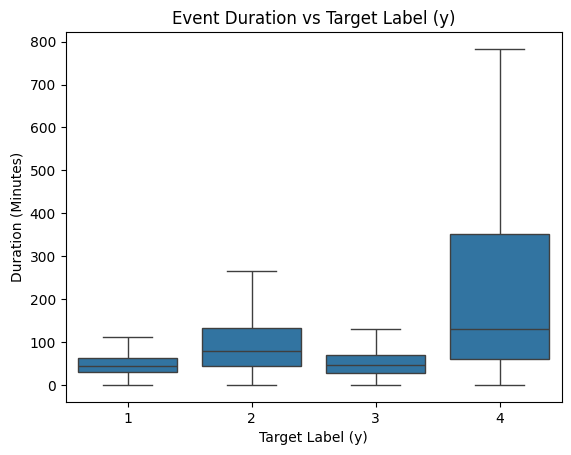

In [79]:
# we draw boxplot of dutation betwen f2 and f13 (f2 - f13) and see if there is any
# meaningful relation between y and this feature.

data['f13'] = pd.to_datetime(data['f13'], format='mixed')
data['f2'] = pd.to_datetime(data['f2'], format='mixed')

data['duration_min'] = (data['f2'] - data['f13']).dt.total_seconds() / 60.0

df_clean = data[data['duration_min'] > 0].copy()

sns.boxplot(data=df_clean, x='y', y='duration_min', showfliers=False)
plt.title('Event Duration vs Target Label (y)')
plt.xlabel('Target Label (y)')
plt.ylabel('Duration (Minutes)')
plt.show()

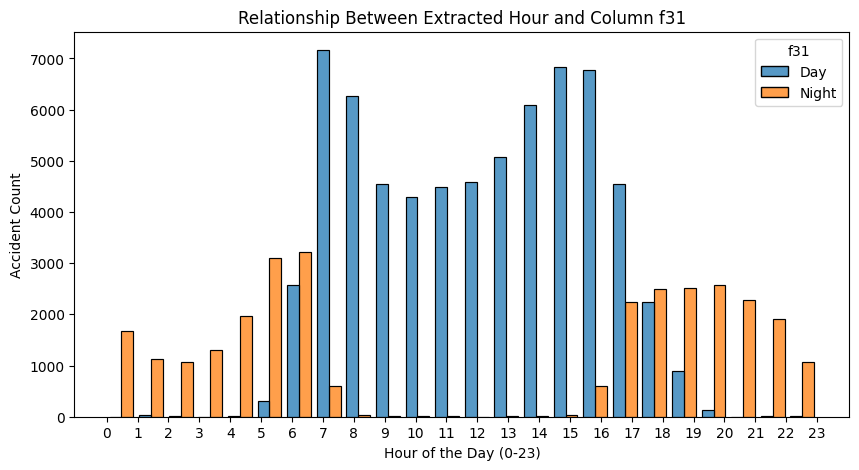

In [80]:
# we use f13 to extract hour, day of the week, and season of the record and save them in different columns.
# then we draw a histogram to see relationship between hour, and 4 columns which are Day/Night (f31, f32, f33, f34)

data['f13'] = pd.to_datetime(data['f13'], format='mixed')

def get_season(month):
    if month in [12, 1, 2]:
        return 4
    elif month in [3, 4, 5]:
        return 1
    elif month in [6, 7, 8]:
        return 2
    else:
        return 3
    
data['hour'] = data['f13'].dt.hour
data['day_of_week'] = data['f13'].dt.dayofweek
data['season'] = data['f13'].dt.month.apply(get_season)

plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='hour', hue='f31', multiple='dodge', bins=24, shrink=0.8)
plt.title('Relationship Between Extracted Hour and Column f31')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Accident Count')
plt.xticks(range(0, 24))
plt.show()

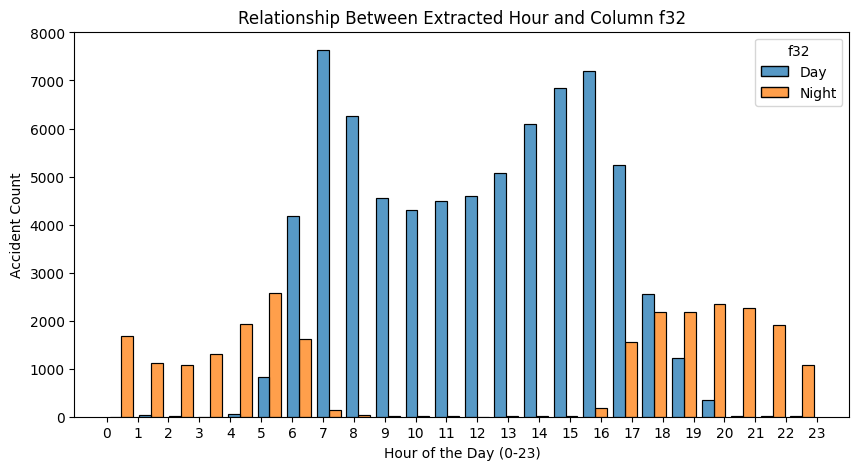

In [81]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='hour', hue='f32', multiple='dodge', bins=24, shrink=0.8)
plt.title('Relationship Between Extracted Hour and Column f32')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Accident Count')
plt.xticks(range(0, 24))
plt.show()

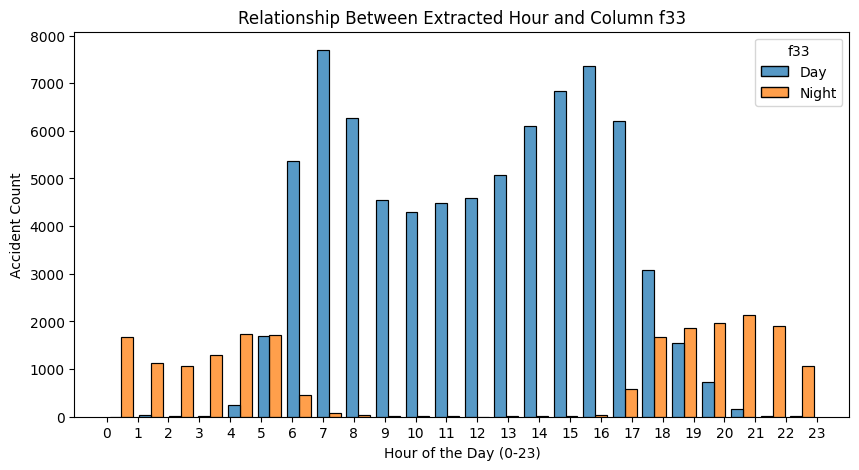

In [82]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='hour', hue='f33', multiple='dodge', bins=24, shrink=0.8)
plt.title('Relationship Between Extracted Hour and Column f33')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Accident Count')
plt.xticks(range(0, 24))
plt.show()

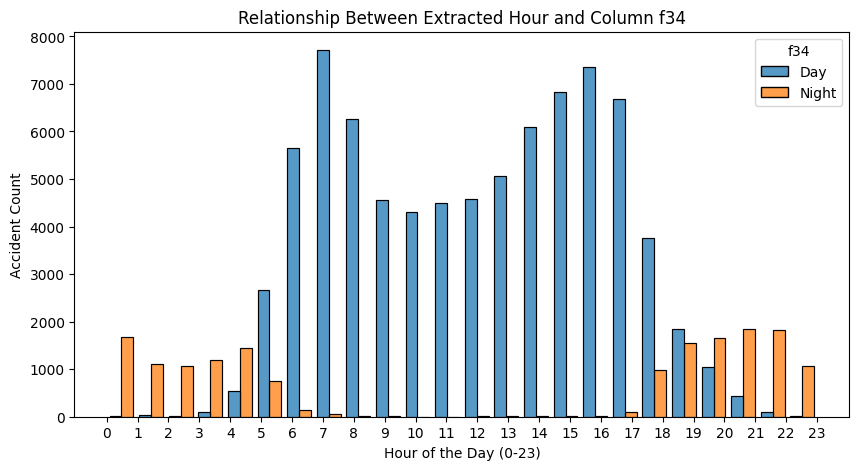

In [83]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='hour', hue='f34', multiple='dodge', bins=24, shrink=0.8)
plt.title('Relationship Between Extracted Hour and Column f34')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Accident Count')
plt.xticks(range(0, 24))
plt.show()

In [84]:
# we drop these 4 columns becuase they show high colinearity with `hour`
data = data.drop(columns=['f31', 'f32', 'f33', 'f34'])

In [85]:
# we drop these f2 and f13 cause their information is extracted and they're not needed anymore.
data = data.drop(columns=['f2', 'f13'])
data.columns

Index(['f1', 'f3', 'f4', 'f6', 'f9', 'f10', 'f12', 'f15', 'f16', 'f17', 'f18',
       'f19', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29',
       'f30', 'y', 'duration_min', 'hour', 'day_of_week', 'season'],
      dtype='object')

In [86]:
# frequency encoding for high cardinal columns
cols = ['f9', 'f10', 'f18', 'f21']

for col in cols:
    freq = data[col].value_counts()
    data[col] = data[col].map(freq)

In [87]:
# ont-hot-oncoding for categorical dtypes
cols = ['f1', 'f12']

data = pd.get_dummies(
    data,
    columns=cols,
    dtype='int64'
)

In [88]:
# columns standardization
num_cols = [
    col for col in data.select_dtypes(include='number').columns
    if col != 'y'
]

scaler = StandardScaler()

data[num_cols] = scaler.fit_transform(data[num_cols])
data[num_cols] = data[num_cols].round(2)

In [89]:
# number of duplicate rows
data.duplicated().sum()

np.int64(122)

In [90]:
# getting rid of duplicate rows
data = data.drop_duplicates()

In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96676 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   f3               96676 non-null  float64
 1   f4               96676 non-null  float64
 2   f6               96676 non-null  float64
 3   f9               96676 non-null  float64
 4   f10              96676 non-null  float64
 5   f15              96676 non-null  float64
 6   f16              96676 non-null  float64
 7   f17              96676 non-null  float64
 8   f18              96676 non-null  float64
 9   f19              96676 non-null  float64
 10  f21              96676 non-null  float64
 11  f22              96676 non-null  bool   
 12  f23              96676 non-null  bool   
 13  f24              96676 non-null  bool   
 14  f25              96676 non-null  bool   
 15  f26              96676 non-null  bool   
 16  f27              96676 non-null  bool   
 17  f28              

In [92]:
print(data["duration_min"].describe())

count    96676.000000
mean        -0.000332
std          1.000595
min         -0.100000
25%         -0.030000
50%         -0.030000
75%         -0.020000
max        133.390000
Name: duration_min, dtype: float64


In [93]:
print(data["f1_Source3"].describe())

count    96676.000000
mean         0.004082
std          1.000020
min         -0.110000
25%         -0.110000
50%         -0.110000
75%         -0.110000
max          8.770000
Name: f1_Source3, dtype: float64


In [94]:
print(data["f12_US/Mountain"].describe())

count    96676.000000
mean        -0.001811
std          0.999226
min         -0.240000
25%         -0.240000
50%         -0.240000
75%         -0.240000
max          4.190000
Name: f12_US/Mountain, dtype: float64


In [95]:
# dropping duration_min, f1_Source3, f12_US/Mountain because each have fairly an standard deviation of 1
data = data.drop(columns=['duration_min', 'f1_Source3', 'f12_US/Mountain'])
data.columns

Index(['f3', 'f4', 'f6', 'f9', 'f10', 'f15', 'f16', 'f17', 'f18', 'f19', 'f21',
       'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'y',
       'hour', 'day_of_week', 'season', 'f1_Source1', 'f1_Source2',
       'f12_US/Central', 'f12_US/Eastern', 'f12_US/Pacific'],
      dtype='object')

In [96]:
data.to_csv('train_data/preprocessed_train.csv', index=False)